In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/Fitness_Membership_Analytics_Dataset.csv')
df.head()

,age,membership_type,visit_per_week,days_per_week,attend_group_lesson,avg_time_check_in,avg_time_check_out,duration_in_gym_minutes,has_drink_subscription,personal_training,...,discount_rate,final_price,access_hours,home_gym_location,latitude,longitude,join_date,personal_training_hours,multi_location_access,last_visit_date
0,40,Premium,2,"Sat, Thu",False,08:39:00,10:37:00,118,False,False,...,0.05,47.5,All hours,"San Jose, CA",37.3382,-121.8863,2024-05-20,0,True,2025-06-30
1,35,Standard,5,"Fri, Sat, Thu, Tue, Wed",True,15:45:00,18:43:00,178,False,False,...,0.00,30.0,Weekdays only,"Fresno, CA",36.7378,-119.7871,2022-09-14,0,False,2025-05-26
2,39,Standard,4,"Sun, Thu, Tue, Wed",True,13:35:00,14:37:00,62,True,True,...,0.10,27.0,Weekdays only,"Oakland, CA",37.8044,-122.2712,2023-05-05,4,False,2025-06-09
3,35,Basic,2,"Mon, Tue",False,17:06:00,18:39:00,93,True,True,...,0.00,20.0,Off-peak only,"Anaheim, CA",33.8366,-117.9143,2023-09-24,7,False,2025-06-17
4,18,Standard,2,"Sun, Wed",False,14:16:00,16:57:00,161,True,True,...,0.10,27.0,Weekdays only,"Sacramento, CA",38.5816,-121.4944,2025-01-07,3,True,2025-07-13


In [3]:
df.describe()

,age,visit_per_week,duration_in_gym_minutes,subscription_price,adjusted_price,discount_rate,final_price,latitude,longitude,personal_training_hours
count,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000
mean,30.591091,2.676176,104.818819,40.140140,36.596847,0.057858,34.471384,35.818505,-119.801068,2.305806
std,10.740041,1.234110,43.363542,15.457645,14.860914,0.058296,14.266186,1.994180,1.864262,2.758167
min,12.000000,1.000000,30.000000,20.000000,15.000000,0.000000,12.750000,32.715700,-122.419400,0.000000
25%,21.000000,2.000000,67.000000,30.000000,22.500000,0.000000,22.500000,33.836600,-121.886300,0.000000
50%,30.000000,3.000000,103.000000,50.000000,37.500000,0.050000,31.875000,36.737800,-119.787100,1.000000
75%,40.000000,3.000000,142.000000,50.000000,50.000000,0.100000,45.000000,37.774900,-118.193700,5.000000
max,49.000000,5.000000,180.000000,70.000000,70.000000,0.150000,70.000000,38.581600,-117.161100,8.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      1998 non-null   int64  
 1   membership_type          1998 non-null   object 
 2   visit_per_week           1998 non-null   int64  
 3   days_per_week            1998 non-null   object 
 4   attend_group_lesson      1998 non-null   bool   
 5   avg_time_check_in        1998 non-null   object 
 6   avg_time_check_out       1998 non-null   object 
 7   duration_in_gym_minutes  1998 non-null   int64  
 8   has_drink_subscription   1998 non-null   bool   
 9   personal_training        1998 non-null   bool   
 10  uses_sauna               1998 non-null   bool   
 11  self_identified_gender   1998 non-null   object 
 12  subscription_price       1998 non-null   int64  
 13  subscription_model       1998 non-null   object 
 14  adjusted_price          

### Tạo các cột ngày trong tuần dựa vào cột days_per_week

In [1]:
from PIL import Image

input_path = r"../Report with power Bi/dash_board.png"
output_path = r"../Report with power Bi/dash_board_resized.png"

with Image.open(input_path) as img:
    resized = img.resize((1280, 720), Image.LANCZOS)
    resized.save(output_path)

In [4]:
days_of_week = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Tạo 7 cột mới bằng cách kiểm tra sự tồn tại của tên ngày trong chuỗi
for day in days_of_week:
    df[day] = df['days_per_week'].apply(lambda x: 1 if day in str(x) else 0)

# Hiển thị thử vài dòng đầu để kiểm tra kết quả
print(df[['days_per_week'] + days_of_week].head())

             days_per_week  Mon  Tue  Wed  Thu  Fri  Sat  Sun
0                 Sat, Thu    0    0    0    1    0    1    0
1  Fri, Sat, Thu, Tue, Wed    0    1    1    1    1    1    0
2       Sun, Thu, Tue, Wed    0    1    1    1    0    0    1
3                 Mon, Tue    1    1    0    0    0    0    0
4                 Sun, Wed    0    0    1    0    0    0    1


In [8]:
df['discount_type'].value_counts()

discount_type
Promo      389
Student    385
Loyalty    384
Name: count, dtype: int64

In [9]:
df['discount_rate'].value_counts()

discount_rate
0.00    840
0.05    389
0.15    385
0.10    384
Name: count, dtype: int64

C:\Users\pc\AppData\Local\Temp\ipykernel_18932\2794518061.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='Set2')


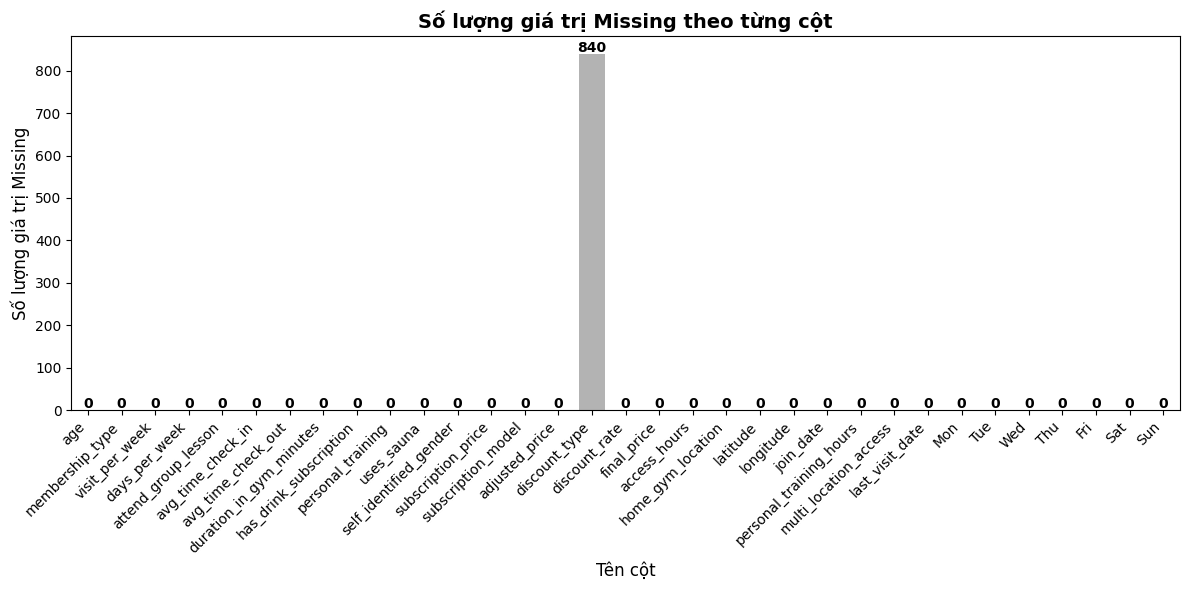

In [6]:
# Tính số lượng giá trị missing của từng cột
missing_counts = df.isna().sum()
# missing_counts = missing_counts[missing_counts > 0]  # Chỉ lấy các cột có giá trị missing

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='Set2')

# Thêm tiêu đề và nhãn
plt.title('Số lượng giá trị Missing theo từng cột', fontsize=14, fontweight='bold')
plt.xlabel('Tên cột', fontsize=12)
plt.ylabel('Số lượng giá trị Missing', fontsize=12)

# Hiển thị số liệu cụ thể trên đầu mỗi cột
for i, v in enumerate(missing_counts.values):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Điền các giá trị na của cột discount_type là No Discount

In [5]:
df['discount_type'] = df['discount_type'].fillna('No Discount')

### Lưu file dữ liệu đã được xử lí để phân tích

In [11]:
df.to_csv('data/fitness_cleaned.csv', index=False)

C:\Users\pc\AppData\Local\Temp\ipykernel_16680\4080372504.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='magma')


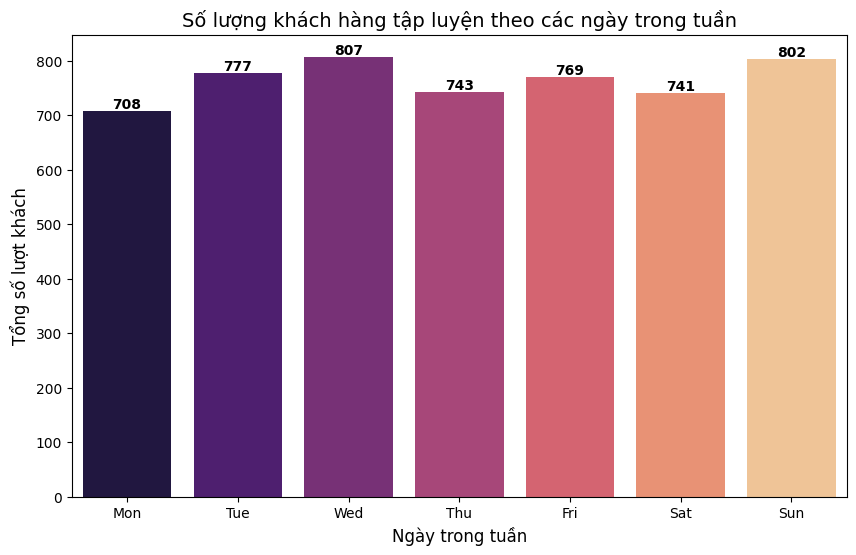

In [5]:
# Danh sách các cột ngày đã tạo ở bước trước
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Tính tổng số lượt tập cho mỗi ngày
day_counts = df[days].sum()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='magma')

# Thêm tiêu đề và nhãn
plt.title('Số lượng khách hàng tập luyện theo các ngày trong tuần', fontsize=14)
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Tổng số lượt khách', fontsize=12)

# Hiển thị số liệu cụ thể trên đầu mỗi cột
for i, v in enumerate(day_counts.values):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

# plt.savefig('visits_by_day.png')
plt.show()

Text(0.5, 1.0, 'Distribution of Access Hours')

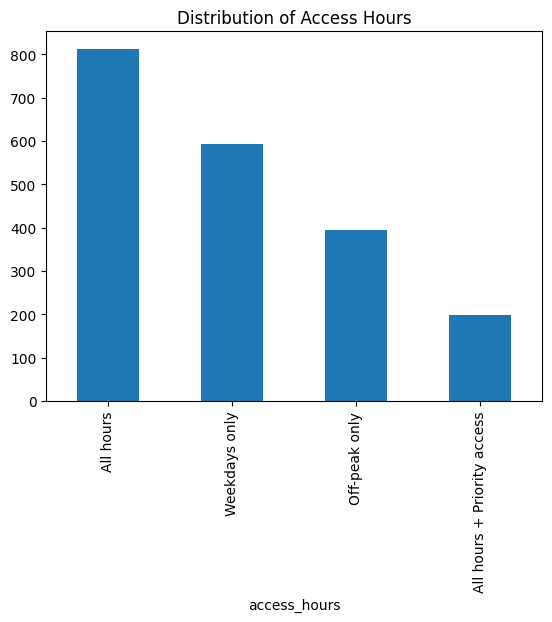

In [11]:
df['access_hours'].value_counts().plot(kind='bar')
plt.title('Distribution of Access Hours')

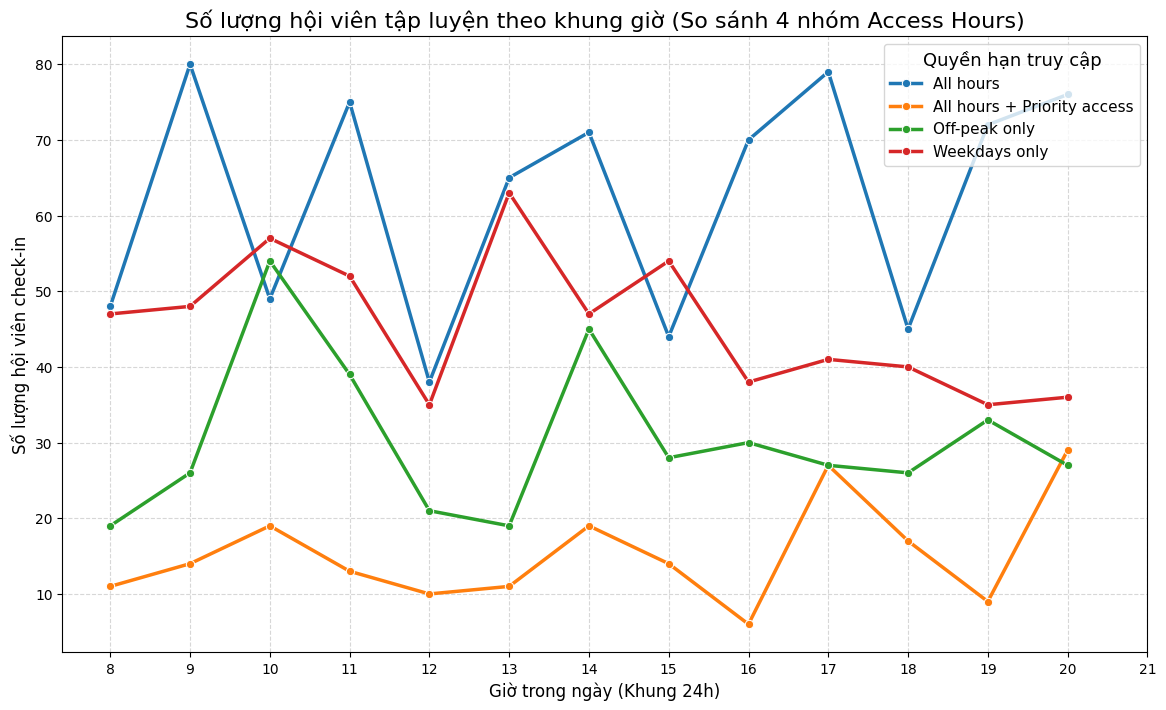

In [10]:
# 1. Trích xuất giờ check-in từ dữ liệu thời gian
df['check_in_hour'] = pd.to_datetime(df['avg_time_check_in'], format='%H:%M:%S').dt.hour

# 2. Nhóm dữ liệu theo loại thẻ và giờ để đếm số lượng người tập
hourly_access_counts = df.groupby(['access_hours', 'check_in_hour']).size().reset_index(name='count')

# 3. Vẽ biểu đồ đường
plt.figure(figsize=(14, 8))
sns.lineplot(data=hourly_access_counts, x='check_in_hour', y='count', 
             hue='access_hours', marker='o', linewidth=2.5)

# 4. Tùy chỉnh hiển thị
plt.title('Số lượng hội viên tập luyện theo khung giờ (So sánh 4 nhóm Access Hours)', fontsize=16)
plt.xlabel('Giờ trong ngày (Khung 24h)', fontsize=12)
plt.ylabel('Số lượng hội viên check-in', fontsize=12)
plt.xticks(range(8, 22)) # Dữ liệu thực tế tập trung từ 8h đến 20h
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Quyền hạn truy cập', title_fontsize='13', fontsize='11', loc='upper right')

plt.show()

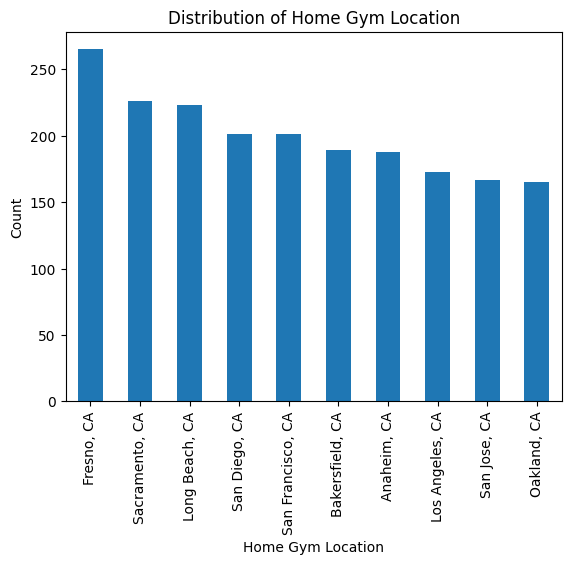

In [3]:
df['home_gym_location'].value_counts().plot(kind='bar')
plt.title('Distribution of Home Gym Location')
plt.xlabel('Home Gym Location')
plt.ylabel('Count')
plt.show()

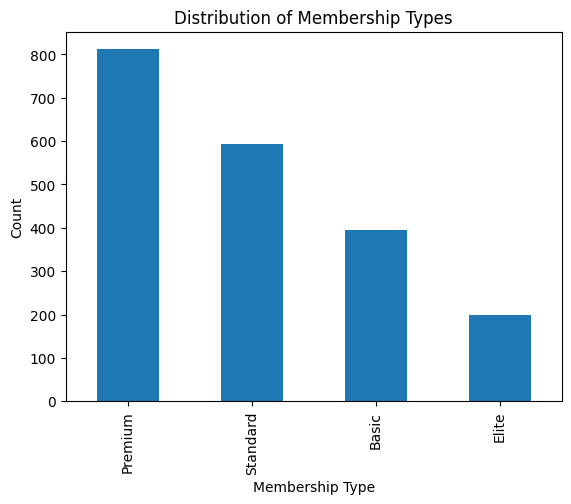

In [4]:
df['membership_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Membership Types')
plt.xlabel('Membership Type')
plt.ylabel('Count')
plt.show()

AttributeError: 'Series' object has no attribute 'value_count'